# Wine Classification

## Problem Understanding

The goal of this project is to build a machine learning model that can determine the type of wine based on its chemical characteristics.<br>

This is a Multiclass Classification problem.
- The model must predict which class a sample belongs to

Target Variable:
- Wine Class (predict which class a sample belongs to)

Input Features:
- Alcohol
- Malic acid
- Magnesium
- Flavanoids
- Color intensity and other chemical attributes

Objective: To build a model that predicts the type of wine based on its chemical properties.

## Import Libraries

Import the necessary libraries for data manipulation, visualization, and machine learning.

In [57]:
# TODO: Import pandas, numpy, matplotlib.pyplot, seaborn
# TODO: Import train_test_split, StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your scikit-learn imports below:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


## Data Loading & Overview


In [2]:
from sklearn.datasets import load_wine

# Load the dataset
wine_dt = load_wine(as_frame = True)
df = wine_dt.frame
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
print("shape")
print(df.shape)

print("Data info:")
df.info()

print("\nBasic Statistics:")
print(df.describe())

shape
(178, 14)
Data info:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    fl

## Data Cleaning

In [4]:
# Check missing values
print("Does this Dataset contain any null values")
print(df.isnull().sum())

# Check duplicates
print("Duplicate check if any")
print(df.duplicated().sum())

Does this Dataset contain any null values
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
Duplicate check if any
0


## EDA & Visualisation

<Axes: xlabel='alcohol', ylabel='Count'>

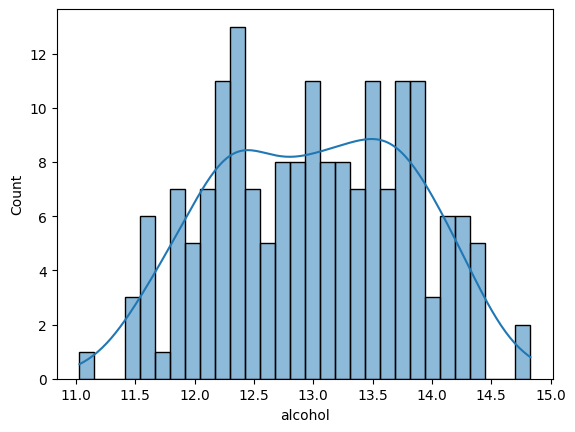

In [6]:
sns.histplot(df['alcohol'], kde=True, bins=30)

<Axes: >

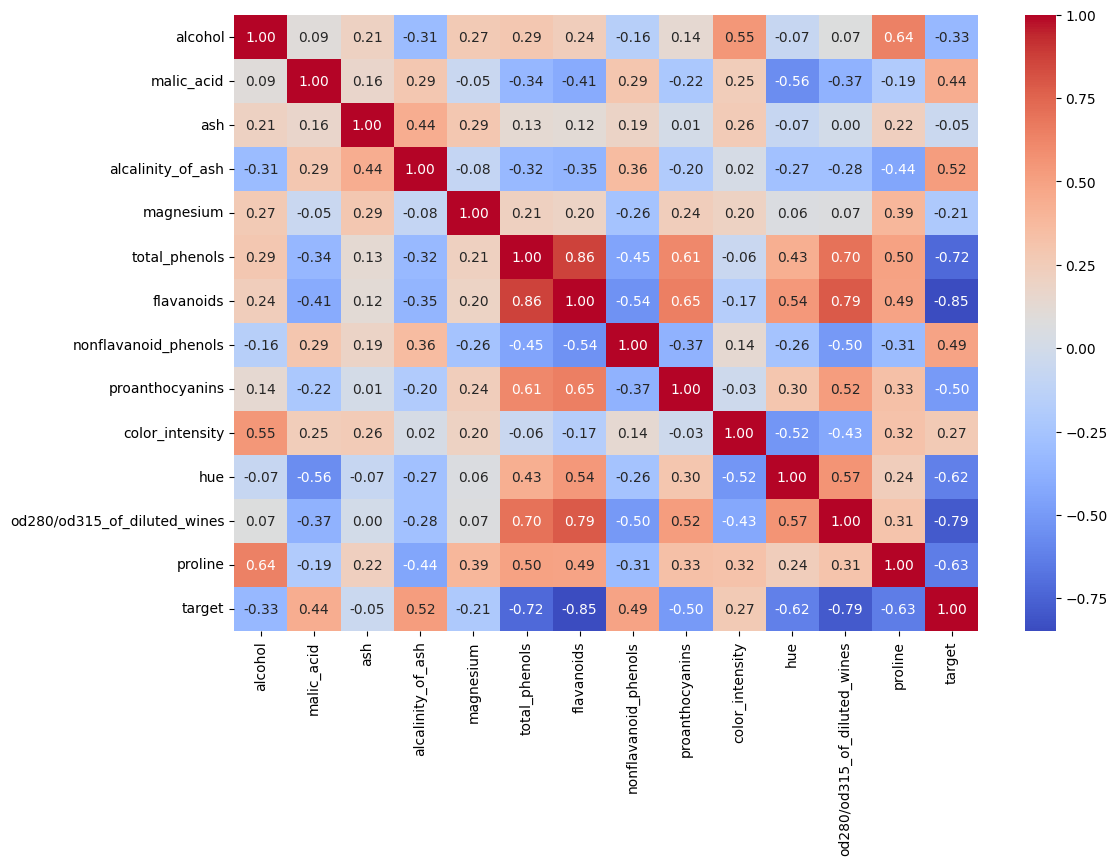

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

## Data Preprocesssing

In [33]:
X = df.drop("target", axis=1)
y = df["target"]

# TODO: 2. Split the data into Training and Testing sets (e.g., 80% train, 20% test)
# Hint: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (142, 13)
X_test shape: (36, 13)
y_train shape: (142,)
y_test shape: (36,)


## Scaling

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [47]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Descision Tree
dec_tr = DecisionTreeClassifier(random_state=40, max_depth=10)
dec_tr.fit(X_train, y_train)
y_pred_dec_tr = dec_tr.predict(X_test)

## Model Evaluation

In [48]:
from sklearn.metrics import accuracy_score

def model_eval(y_true, y_pred, name="Model"):
    accuracy = accuracy_score(y_true, y_pred)
    print(f"{name} -> Accuracy: {accuracy:.2f}")

model_eval(y_test, y_pred_lr, "Logistic Regression")
model_eval(y_test, y_pred_dec_tr, "Decision Tree")

Logistic Regression -> Accuracy: 1.00
Decision Tree -> Accuracy: 0.94


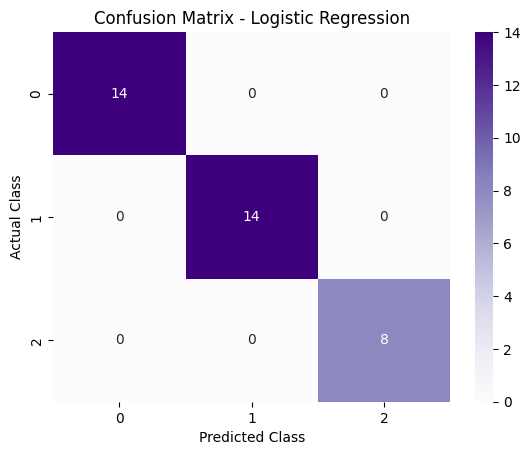

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, cmap="Purples", fmt='d')
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()